<a href="https://colab.research.google.com/github/kukanmani06/PRODIGY_ML_01/blob/main/House_Price_Predition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [2]:
house_data=pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/house_sales_data.csv")

In [3]:
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
house_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


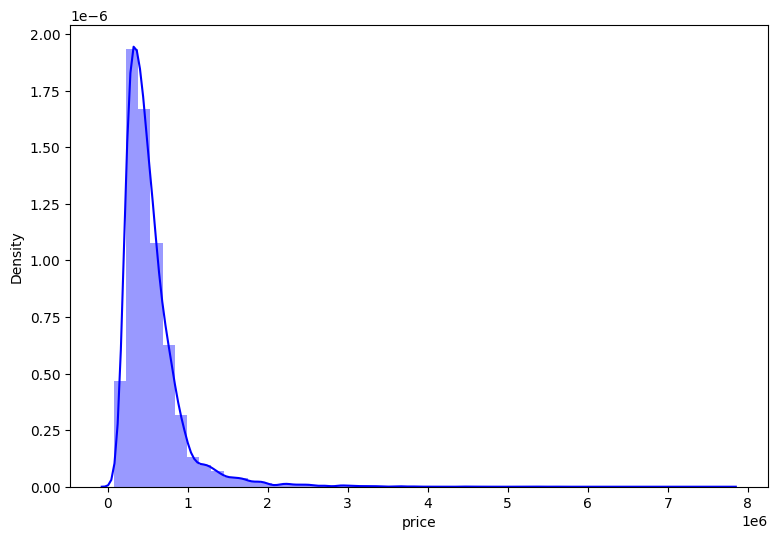

In [6]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(9,6))
sns.distplot(house_data['price'], color='blue')
plt.show()

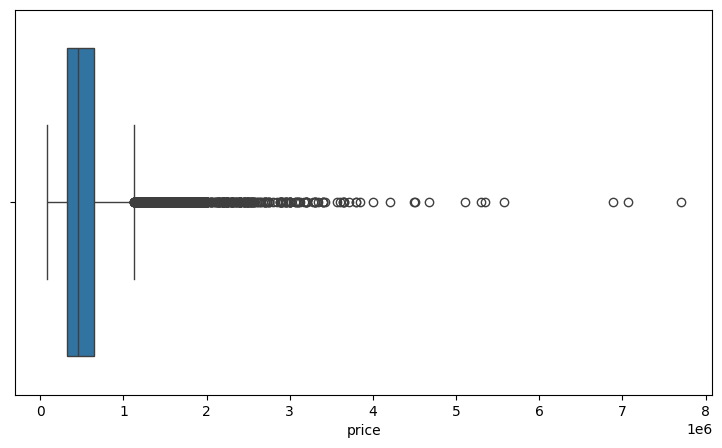

In [7]:
plt.figure(figsize=(9,5))
sns.boxplot(house_data['price'], orient = 'h')
plt.show()

In [8]:
house_df = house_data.drop(['id', 'date'], axis = 1)

In [9]:
def outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    # Inter quartile range
    IQR = Q3 - Q1
    # Outlier
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    mask = (df[column] < lower_limit) | (df[column] > upper_limit)
    return df.index[mask]

In [10]:
outliers(house_df, 'price')

Index([    5,    21,    49,    69,   125,   153,   216,   246,   269,   270,
       ...
       21525, 21530, 21532, 21540, 21551, 21568, 21576, 21590, 21597, 21600],
      dtype='int64', length=1146)

In [11]:
Q1 = house_df['price'].quantile(0.25)
Q3 = house_df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

In [13]:
house_df['price'] = house_df['price'].clip(lower = lower_limit, upper = upper_limit)

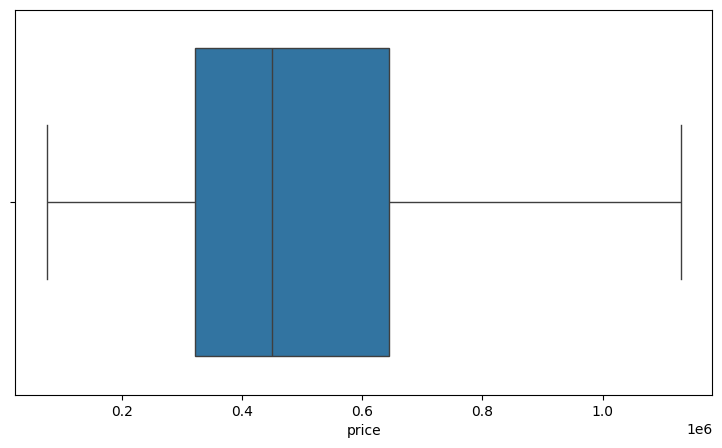

In [14]:
plt.figure(figsize=(9,5))
sns.boxplot(house_df['price'], orient = 'h')
plt.show()

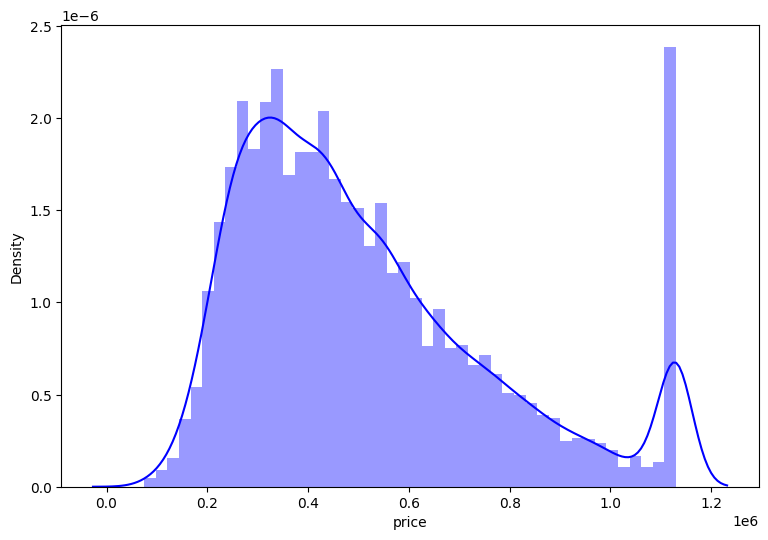

In [15]:
plt.figure(figsize=(9,6))
sns.distplot(house_df['price'], color='blue')
plt.show()

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
x = house_df.drop('price', axis = 1)

In [18]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif_data

,feature,VIF
0,bedrooms,2.327239e+01
1,bathrooms,2.861188e+01
2,sqft_living,inf
3,sqft_lot,2.377656e+00
4,floors,1.689222e+01
5,waterfront,1.212827e+00
6,view,1.551834e+00
7,condition,3.471167e+01
8,grade,1.473809e+02
9,sqft_above,inf


In [22]:
X = house_df[['sqft_living', 'bedrooms', 'bathrooms']]
Y = house_df['price']



In [23]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,feature,VIF
0,sqft_living,15.645129
1,bedrooms,12.027156
2,bathrooms,18.521585


In [24]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [25]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

LinearRegression()

In [26]:
lr_model.score(x_test, y_test)

0.5001010222017945

In [27]:
b0 = lr_model.intercept_
print(b0)

160676.76673474477


In [28]:
coeff = lr_model.coef_
print(coeff)

[   194.79916687 -25673.6690626   15734.93137697]


In [29]:
yhat = lr_model.predict(x_test)

In [30]:
yhat = lr_model.predict(x_test)

In [31]:
mean_absolute_error(y_test, yhat)

139620.0585514043

In [32]:
r2_score(y_test, yhat)

0.5001010222017945

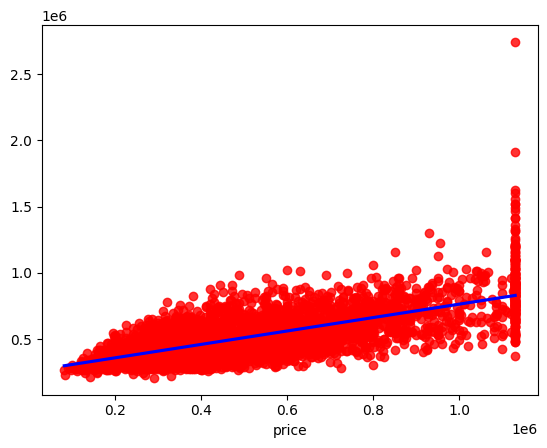

In [33]:
sns.regplot(x = y_test, y = yhat, ci = None, color = "r", line_kws={"color":"blue"})
plt.show()

In [34]:
x_new = x_test.sample(1)

In [35]:
lr_model.predict(x_new)

array([633366.9051839])